# Fill Hazard & Survival Analysis

Addresses the key critique of the fixed-window kappa estimation:
orders that get cancelled before filling are **right-censored observations**,
not failures. This notebook estimates the instantaneous fill hazard `h(t, δ)`
using survival analysis.

**The survival setup:**
- Each synthetic order has a lifetime from `t_submit + latency` until first fill or cancellation
- If a fill occurs: event observed, time-to-fill recorded
- If cancelled before fill: right-censored at the cancellation time
- The hazard rate `h(t, δ)` = instantaneous fill probability per unit time at distance δ
- Integrating over order lifetime gives P(fill before cancellation | δ, lifetime)

**Key advantages over fixed-window approach:**
- Order lifetime is a free parameter, not fixed at `quote_interval`
- Cancellations are treated correctly as censored, not as non-fills
- Produces `h(δ)` that can be used with any order lifetime distribution
- Directly supports the hysteresis/decoupled recomputation architecture

## Sections
1. Setup
2. Synthetic order simulation with variable lifetime
3. Kaplan-Meier survival curves by spread distance
4. Parametric hazard estimation — Weibull and exponential
5. Nonparametric fill probability P(fill | δ, T) for any lifetime T
6. Comparison with fixed-window approach
7. Hysteresis analysis — how often would quotes actually change?
8. Summary

## 1. Setup

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.optimize import curve_fit, minimize
from scipy.stats import weibull_min, expon
import warnings
warnings.filterwarnings('ignore')

import sys
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from hft_market_maker.core.fill_analysis import (
    load_day, compute_fill_curve, empirical_fill_prob,
    fit_exponential, simulate_fill_curve,
    fit_shifted_exponential, shifted_exponential, compare_fits,
)

try:
    from lifelines import KaplanMeierFitter, WeibullAFTFitter, CoxPHFitter
    HAS_LIFELINES = True
    print('lifelines available')
except ImportError:
    HAS_LIFELINES = False
    print('lifelines not installed — pip install lifelines')
    print('Falling back to manual KM estimator')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

# ── Config ────────────────────────────────────────────────────────
DATA_DIR       = Path('../data/real')
DATE           = '2025-05-13'
TICK           = 0.01
LATENCY        = 0.10
RECOMPUTE_FREQ = 0.10   # recompute optimal quotes every 100ms
MAX_LIFETIME   = 10.0   # seconds — maximum order lifetime to simulate
TOLERANCE_TICKS = 1   # hysteresis: only cancel if new quote differs by > this
DELTAS         = np.arange(0.5, 10.5, 1.0)  # spread distances to analyse
DELTAS = np.array([
    1.5, 2.5, 3.5, 4.5, 5.5,       # dense — most of the decay happens here
    7.5, 10.0, 15.0, 20.0, 25.0,         # sparse — flat tail, just confirming the floor
    30.0,40.0, 50.0, 75.0,100.0               # very sparse — confirming floor doesn't decay further
])
# ─────────────────────────────────────────────────────────────────

trades, quotes = load_day(DATE, DATA_DIR)
merged_all = compute_fill_curve(trades, quotes)
print(f'Trades: {len(trades):,}  Quotes: {len(quotes):,}  Fresh: {len(merged_all):,}')

lifelines available
Trades: 3,476,024  Quotes: 681,990  Fresh: 3,411,517


## 2. Synthetic Order Simulation with Variable Lifetime

For each synthetic order at distance δ, record:
- `time_to_fill`: seconds from activation until fill (if filled)
- `time_to_cancel`: seconds from activation until cancellation
- `filled`: 1 if filled before max_lifetime, 0 if censored
- `observed_time`: min(time_to_fill, time_to_cancel) — the survival time

In [20]:
def simulate_survival_data(
    trades, quotes,
    half_spread_ticks,
    latency=LATENCY,
    max_lifetime=MAX_LIFETIME,
    recompute_freq=RECOMPUTE_FREQ,
    tolerance_ticks=TOLERANCE_TICKS,
    max_quote_age_ms=200,
    tick=TICK,
):
    """
    Simulate orders at half_spread_ticks from mid.
    Orders are cancelled when:
      (a) The new optimal quote diverges by > tolerance_ticks from current, OR
      (b) max_lifetime is reached

    Returns DataFrame with survival data:
        delta, observed_time, filled, time_to_fill, time_to_cancel,
        mid_at_submit, censored_reason
    """
    half_spread = half_spread_ticks * tick
    tolerance   = tolerance_ticks * tick

    trades_ts  = (trades['ts'].astype(np.int64) / 1e9).values
    trades_px  = trades['price'].values
    quotes_ts  = (quotes['ts'].astype(np.int64) / 1e9).values
    quotes_mid = quotes['mid'].values

    t_min = trades_ts[0]
    t_max = trades_ts[-1]

    results = []
    t = t_min

    while t < t_max - max_lifetime:
        # Find mid at submission time
        q_idx = np.searchsorted(quotes_ts, t, side='right') - 1
        if q_idx < 0:
            t += recompute_freq
            continue

        quote_age = (t - quotes_ts[q_idx]) * 1000
        if quote_age > max_quote_age_ms:
            t += recompute_freq
            continue

        mid_submit = quotes_mid[q_idx]
        bid = mid_submit - half_spread
        ask = mid_submit + half_spread

        # Order becomes active after latency
        active_from = t + latency
        filled = False
        fill_time = None
        cancel_time = None
        censored_reason = None

        # Scan forward in recompute_freq steps
        t_check = active_from
        while t_check < active_from + max_lifetime:
            # Check for fills up to this checkpoint
            lo = np.searchsorted(trades_ts, t_check - recompute_freq, side='left')
            hi = np.searchsorted(trades_ts, t_check, side='right')
            window_px = trades_px[lo:hi]

            if len(window_px) > 0:
                bid_fill = np.any(window_px <= bid)
                ask_fill = np.any(window_px >= ask)
                if bid_fill or ask_fill:
                    # Find exact fill time
                    if bid_fill:
                        fill_idx = lo + np.argmax(window_px <= bid)
                    else:
                        fill_idx = lo + np.argmax(window_px >= ask)
                    fill_time = trades_ts[fill_idx] - active_from
                    filled = True
                    break

            # Check if new optimal quote diverges (hysteresis)
            q_now = np.searchsorted(quotes_ts, t_check, side='right') - 1
            if q_now >= 0:
                mid_now = quotes_mid[q_now]
                new_bid = mid_now - half_spread
                new_ask = mid_now + half_spread
                # Cancel if mid moved enough to warrant requote
                if abs(new_bid - bid) > tolerance:
                    cancel_time = t_check - active_from
                    censored_reason = 'diverged'
                    break

            t_check += recompute_freq

        if not filled and cancel_time is None:
            cancel_time = max_lifetime
            censored_reason = 'timeout'

        observed_time = fill_time if filled else cancel_time

        results.append({
            'delta':          half_spread_ticks,
            'observed_time':  observed_time,
            'filled':         int(filled),
            'time_to_fill':   fill_time,
            'time_to_cancel': cancel_time,
            'mid_at_submit':  mid_submit,
            'censored_reason': censored_reason,
            'submit_time':    t,
        })
        t += recompute_freq

    return pd.DataFrame(results)

def simulate_survival_data_fast(
    trades, quotes,
    half_spread_ticks,
    
    max_lifetime,
    recompute_freq,
    tolerance_ticks,
    latency=LATENCY,
    max_quote_age_ms=200,
    tick=TICK,
):
    half_spread = half_spread_ticks * tick
    tolerance   = tolerance_ticks * tick

    trades_ts  = (trades['ts'].astype(np.int64) / 1e9).values
    trades_px  = trades['price'].values
    quotes_ts  = (quotes['ts'].astype(np.int64) / 1e9).values
    quotes_mid = quotes['mid'].values

    t_min = trades_ts[0]
    t_max = trades_ts[-1] - max_lifetime

    # Generate all submission times at once
    submit_times = np.arange(t_min, t_max, recompute_freq)

    # Vectorised mid lookup at submission time
    q_indices = np.searchsorted(quotes_ts, submit_times, side='right') - 1
    valid = q_indices >= 0
    submit_times = submit_times[valid]
    q_indices    = q_indices[valid]

    quote_ages = (submit_times - quotes_ts[q_indices]) * 1000
    fresh = quote_ages < max_quote_age_ms
    submit_times = submit_times[fresh]
    q_indices    = q_indices[fresh]

    mids_at_submit = quotes_mid[q_indices]
    bids = mids_at_submit - half_spread
    asks = mids_at_submit + half_spread

    results = []

    for i, (t, mid_submit, bid, ask) in enumerate(
            zip(submit_times, mids_at_submit, bids, asks)):

        active_from = t + latency
        active_to   = active_from + max_lifetime

        # All trades in the full lifetime window — one searchsorted per order
        lo = np.searchsorted(trades_ts, active_from, side='left')
        hi = np.searchsorted(trades_ts, active_to,   side='right')
        window_ts = trades_ts[lo:hi]
        window_px = trades_px[lo:hi]

        if len(window_ts) == 0:
            results.append({
                'delta': half_spread_ticks,
                'observed_time': max_lifetime,
                'filled': 0,
                'time_to_fill': None,
                'time_to_cancel': max_lifetime,
                'censored_reason': 'timeout',
                'submit_time': t,
            })
            continue

        # Fill times — first trade hitting bid or ask
        bid_hits = window_ts[window_px <= bid]
        ask_hits = window_ts[window_px >= ask]
        fill_candidates = []
        if len(bid_hits) > 0: fill_candidates.append(bid_hits[0])
        if len(ask_hits) > 0: fill_candidates.append(ask_hits[0])

        fill_time = (min(fill_candidates) - active_from) if fill_candidates else None

        # Divergence times — when mid moves beyond tolerance
        q_window_idx = np.searchsorted(quotes_ts, window_ts, side='right') - 1
        q_window_idx = np.clip(q_window_idx, 0, len(quotes_mid) - 1)
        mids_during  = quotes_mid[q_window_idx]
        diverged     = np.abs(mids_during - mid_submit) > tolerance
        cancel_time  = (window_ts[diverged][0] - active_from) if diverged.any() else max_lifetime
        censored_reason = 'diverged' if diverged.any() else 'timeout'

        if fill_time is not None and fill_time <= cancel_time:
            results.append({
                'delta': half_spread_ticks,
                'observed_time': fill_time,
                'filled': 1,
                'time_to_fill': fill_time,
                'time_to_cancel': None,
                'censored_reason': None,
                'submit_time': t,
            })
        else:
            results.append({
                'delta': half_spread_ticks,
                'observed_time': cancel_time,
                'filled': 0,
                'time_to_fill': None,
                'time_to_cancel': cancel_time,
                'censored_reason': censored_reason,
                'submit_time': t,
            })

    return pd.DataFrame(results)
# Test on one spread distance first
print('Testing simulation at delta=1.5 ticks...')
test_df = simulate_survival_data_fast(trades, quotes, half_spread_ticks=1.5,max_lifetime=MAX_LIFETIME, 
                                      recompute_freq=RECOMPUTE_FREQ, tolerance_ticks=TOLERANCE_TICKS)
print(f'Orders simulated: {len(test_df):,}')
print(f'Fill rate:        {test_df["filled"].mean():.4f}')
print(f'Censored (diverged): {(test_df["censored_reason"]=="diverged").mean():.4f}')
print(f'Censored (timeout):  {(test_df["censored_reason"]=="timeout").mean():.4f}')
print(f'Mean time to fill:   {test_df[test_df["filled"]==1]["observed_time"].mean():.3f}s')
print(f'Mean time to cancel: {test_df[test_df["filled"]==0]["observed_time"].mean():.3f}s')

Testing simulation at delta=1.5 ticks...
Orders simulated: 769,423
Fill rate:        0.7621
Censored (diverged): 0.0069
Censored (timeout):  0.2310
Mean time to fill:   2.956s
Mean time to cancel: 9.807s


In [30]:
# Run for all spread distances
print(f'Running survival simulation for {len(DELTAS)} spread distances...')
print(f'  recompute_freq={RECOMPUTE_FREQ}s  max_lifetime={MAX_LIFETIME}s  '
      f'tolerance={TOLERANCE_TICKS} ticks')
print()

survival_dfs = {}
summary_rows = []

for d in DELTAS:
    df = simulate_survival_data_fast(trades, quotes, half_spread_ticks=d, max_lifetime=MAX_LIFETIME, 
                                     recompute_freq=RECOMPUTE_FREQ,tolerance_ticks=TOLERANCE_TICKS)
    survival_dfs[d] = df

    fill_rate   = df['filled'].mean()
    n_diverged  = (df['censored_reason'] == 'diverged').sum()
    n_timeout   = (df['censored_reason'] == 'timeout').sum()
    mean_ttf    = df[df['filled']==1]['observed_time'].mean()
    mean_ttc    = df[df['filled']==0]['observed_time'].mean()

    summary_rows.append({
        'delta': d, 'n': len(df), 'fill_rate': fill_rate,
        'n_fills': df['filled'].sum(),
        'n_diverged': n_diverged, 'n_timeout': n_timeout,
        'mean_ttf': mean_ttf, 'mean_ttc': mean_ttc,
    })
    print(f'  delta={d:.1f}  fill={fill_rate:.4f}  '
          f'diverged={n_diverged/len(df):.3f}  timeout={n_timeout/len(df):.3f}  '
          f'mean_ttf={mean_ttf:.2f}s' if not np.isnan(mean_ttf) else
          f'  delta={d:.1f}  fill={fill_rate:.4f}  no fills')

surv_summary = pd.DataFrame(summary_rows)
print(f'\nTotal orders simulated: {surv_summary["n"].sum():,}')

Running survival simulation for 15 spread distances...
  recompute_freq=0.1s  max_lifetime=10.0s  tolerance=1 ticks

  delta=1.5  fill=0.7657  diverged=0.003  timeout=0.232  mean_ttf=2.96s
  delta=2.5  fill=0.7559  diverged=0.011  timeout=0.233  mean_ttf=2.97s
  delta=3.5  fill=0.7535  diverged=0.013  timeout=0.233  mean_ttf=2.97s
  delta=4.5  fill=0.7528  diverged=0.014  timeout=0.233  mean_ttf=2.97s
  delta=5.5  fill=0.7524  diverged=0.014  timeout=0.233  mean_ttf=2.97s
  delta=7.5  fill=0.7509  diverged=0.016  timeout=0.233  mean_ttf=2.97s
  delta=10.0  fill=0.7494  diverged=0.017  timeout=0.233  mean_ttf=2.97s
  delta=15.0  fill=0.7476  diverged=0.019  timeout=0.233  mean_ttf=2.97s
  delta=20.0  fill=0.7452  diverged=0.021  timeout=0.233  mean_ttf=2.97s
  delta=25.0  fill=0.7431  diverged=0.024  timeout=0.233  mean_ttf=2.97s
  delta=30.0  fill=0.7405  diverged=0.026  timeout=0.233  mean_ttf=2.97s
  delta=40.0  fill=0.7368  diverged=0.030  timeout=0.233  mean_ttf=2.97s
  delta=50.0 

In [21]:
for lifetime in [1.0, 2.0, 5.0, 10.0, 30.0, 60.0]:
    df = simulate_survival_data_fast(trades, quotes,
                                     half_spread_ticks=5.0,  # fixed delta
                                     max_lifetime=lifetime, recompute_freq=RECOMPUTE_FREQ, tolerance_ticks=TOLERANCE_TICKS)
    print(f'T={lifetime}s  fill={df["filled"].mean():.3f}  mean_ttf={df[df["filled"]==1]["observed_time"].mean():.2f}s')

T=1.0s  fill=0.238  mean_ttf=0.38s
T=2.0s  fill=0.358  mean_ttf=0.75s
T=5.0s  fill=0.576  mean_ttf=1.72s
T=10.0s  fill=0.745  mean_ttf=2.95s
T=30.0s  fill=0.917  mean_ttf=5.55s
T=60.0s  fill=0.953  mean_ttf=6.87s


In [22]:
for tol in [0.25, 0.5, 1.0, 2.0, 5.0]:
    df = simulate_survival_data_fast(trades, quotes,
                                     half_spread_ticks=5.0,
                                     tolerance_ticks=tol,
                                     max_lifetime=10.0,
                                     recompute_freq=RECOMPUTE_FREQ)
    print(f'tol={tol}  fill={df["filled"].mean():.3f}  '
          f'diverged={( df["censored_reason"]=="diverged").mean():.3f}')

tol=0.25  fill=0.745  diverged=0.024
tol=0.5  fill=0.745  diverged=0.024
tol=1.0  fill=0.752  diverged=0.014
tol=2.0  fill=0.762  diverged=0.002
tol=5.0  fill=0.764  diverged=0.000


## 3. Kaplan-Meier Survival Curves by Spread Distance

S(t | δ) = P(order not yet filled at time t | spread distance δ)

Censored observations (cancelled orders) are handled correctly.

KeyboardInterrupt: 

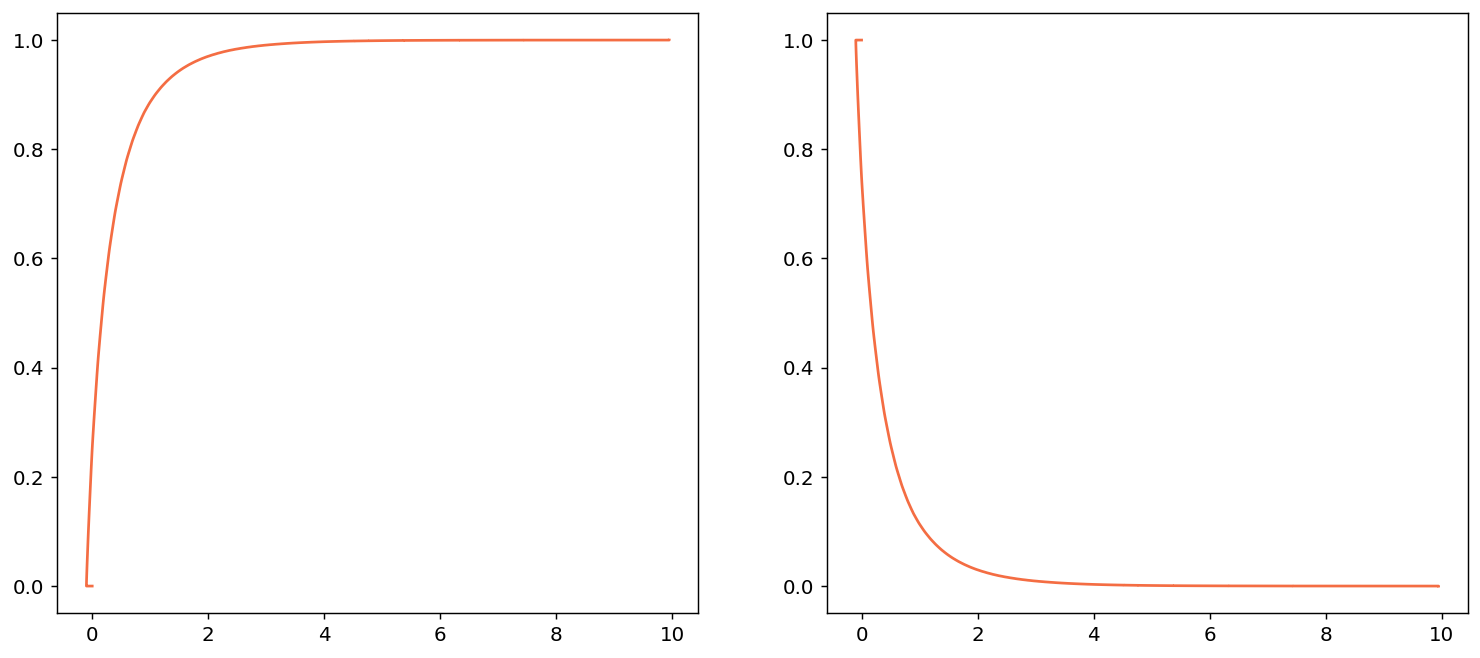

In [5]:
def kaplan_meier(times, events):
    """
    Manual Kaplan-Meier estimator.
    times:  observed times (fill time or censoring time)
    events: 1 if fill observed, 0 if censored
    Returns (t_grid, survival) arrays.
    """
    df = pd.DataFrame({'t': times, 'e': events}).sort_values('t')
    t_vals = np.sort(df[df['e'] == 1]['t'].unique())
    n = len(df)
    S = 1.0
    surv_t = [0.0]
    surv_s = [1.0]

    for t in t_vals:
        n_at_risk = (df['t'] >= t).sum()
        n_events  = ((df['t'] == t) & (df['e'] == 1)).sum()
        if n_at_risk > 0:
            S *= (1 - n_events / n_at_risk)
        surv_t.append(t)
        surv_s.append(S)

    return np.array(surv_t), np.array(surv_s)


# Plot KM curves for selected deltas
plot_deltas = [0.5, 1.5, 2.5, 4.5, 7.5, 9.5]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(plot_deltas)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for d, col in zip(plot_deltas, colors):
    df = survival_dfs[d]
    t_km, s_km = kaplan_meier(df['observed_time'].values, df['filled'].values)

    # S(t) = P(not yet filled) — plot 1 - S(t) = P(filled by time t)
    axes[0].step(t_km, 1 - s_km, where='post', color=col, lw=1.5, label=f'δ={d:.1f}')
    axes[1].step(t_km, s_km,     where='post', color=col, lw=1.5, label=f'δ={d:.1f}')

axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('P(filled by time t)')
axes[0].set_title('Cumulative fill probability F(t | δ)')
axes[0].legend(fontsize=8, title='Half-spread')
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('S(t) = P(not yet filled)')
axes[1].set_title('Survival function S(t | δ)')
axes[1].legend(fontsize=8, title='Half-spread')
axes[1].grid(alpha=0.3)

plt.suptitle(f'Kaplan-Meier Fill Survival — {DATE}  '
             f'(tolerance={TOLERANCE_TICKS} ticks)', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/survival_km_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Parametric Hazard Estimation

Fit parametric survival models to estimate the hazard rate `h(t, δ)`.

**Exponential model:** constant hazard — `h(t) = λ(δ)` independent of time
**Weibull model:** time-varying hazard — `h(t) = (k/λ)(t/λ)^(k-1)`, k>1 = increasing, k<1 = decreasing

In [12]:
def fit_exponential_hazard(times, events):
    """
    MLE for exponential survival model: S(t) = exp(-lambda * t)
    Correctly handles right-censoring.
    lambda_hat = n_events / sum(observed_times)
    """
    n_events = np.sum(events)
    total_time = np.sum(times)
    if total_time < 1e-10 or n_events == 0:
        return None, None
    lam = n_events / total_time
    # SE via Fisher information: SE(lambda) = lambda / sqrt(n_events)
    se  = lam / np.sqrt(n_events)
    return lam, se


def fit_weibull_hazard(times, events):
    """
    MLE for Weibull survival model via negative log-likelihood.
    Returns (shape k, scale lambda, se_k, se_lambda) or None.
    """
    times  = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=float)
    n_events = events.sum()
    if n_events < 5:
        return None

    def neg_ll(params):
        log_k, log_lam = params
        k   = np.exp(log_k)
        lam = np.exp(log_lam)
        # log-likelihood: sum over events of log(h) + sum over all of log(S)
        # h(t) = (k/lam)*(t/lam)^(k-1), S(t) = exp(-(t/lam)^k)
        ll_events  = events * (np.log(k) - np.log(lam) + (k-1)*np.log(times/lam + 1e-10))
        ll_survival= -(times / lam) ** k
        return -np.sum(ll_events + ll_survival)

    try:
        res = minimize(neg_ll, x0=[0.0, np.log(np.mean(times))],
                       method='Nelder-Mead',
                       options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 5000})
        k   = np.exp(res.x[0])
        lam = np.exp(res.x[1])
        return {'k': k, 'lambda': lam, 'converged': res.success}
    except Exception:
        return None


# Fit both models for each spread distance
hazard_results = []
print(f'{"delta":>6} {"n_fills":>8} {"lambda_exp":>12} {"se_lam":>8} '
      f'{"k_weibull":>12} {"lam_weibull":>12}')
print('-' * 65)

for d in DELTAS:
    df = survival_dfs[d]
    times  = df['observed_time'].values.astype(float)
    events = df['filled'].values.astype(float)

    lam_e, se_e = fit_exponential_hazard(times, events)
    weib = fit_weibull_hazard(times, events)

    row = {
        'delta':      d,
        'n_fills':    int(events.sum()),
        'n_total':    len(df),
        'fill_rate':  events.mean(),
        'lambda_exp': lam_e,
        'se_lambda':  se_e,
        'k_weibull':  weib['k']   if weib else np.nan,
        'lam_weibull':weib['lambda'] if weib else np.nan,
        'weib_conv':  weib['converged'] if weib else False,
    }
    hazard_results.append(row)

    k_str = f'{weib["k"]:.4f}' if weib else 'failed'
    l_str = f'{weib["lambda"]:.4f}' if weib else 'failed'
    lam_str = f'{lam_e:.4f}' if lam_e else 'failed'
    se_str  = f'{se_e:.4f}'  if se_e  else ''
    print(f'{d:>6.1f} {int(events.sum()):>8} {lam_str:>12} {se_str:>8} {k_str:>12} {l_str:>12}')

hz = pd.DataFrame(hazard_results)

 delta  n_fills   lambda_exp   se_lam    k_weibull  lam_weibull
-----------------------------------------------------------------
   1.5   574833       0.1634   0.0002       1.0000       4.5724
   2.5   566499       0.1610   0.0002       1.0000       4.5742
   3.5   565170       0.1606   0.0002       1.0000       4.5744
   4.5   564569       0.1604   0.0002       1.0000       4.5745
   5.5   564207       0.1603   0.0002       1.0000       4.5746
   7.5   563294       0.1600   0.0002       1.0000       4.5747
  10.0   562182       0.1597   0.0002       1.0000       4.5749
  15.0   560774       0.1593   0.0002       1.0000       4.5753
  20.0   558661       0.1587   0.0002       1.0000       4.5756
  25.0   556752       0.1581   0.0002       1.0000       4.5760
  30.0   554322       0.1574   0.0002       1.0000       4.5764
  40.0   551256       0.1565   0.0002       1.0000       4.5770
  50.0   547672       0.1555   0.0002       1.0000       4.5777
  75.0   536786       0.1523   0.0002 

Survival hazard — pure exp:    A=0.1888  kappa=0.0100
Survival hazard — shifted:     A_liq=0.0186  kappa=0.0100  A_floor=0.1433
  Momentum fraction: 88.5%


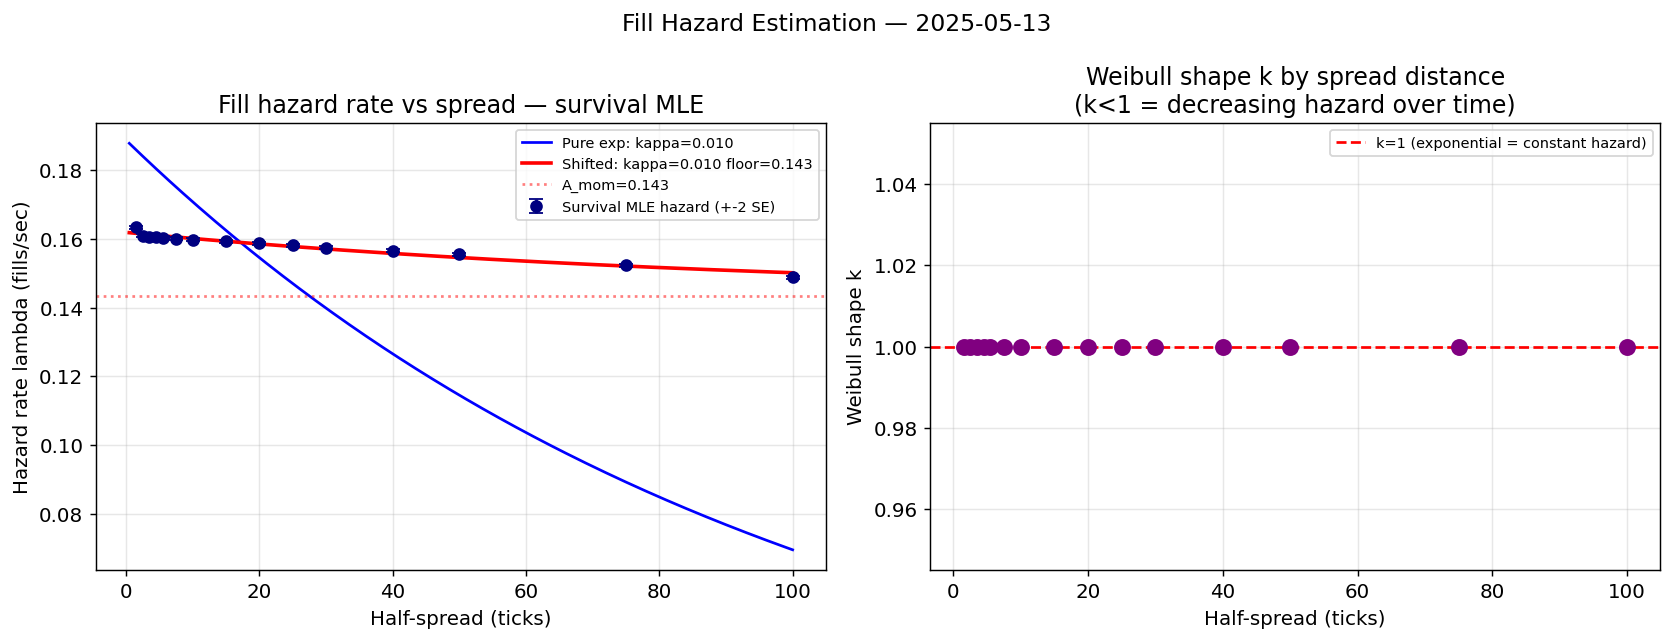

In [13]:
# Fit exponential decay of hazard rate vs delta
# lambda_exp(delta) should follow A * exp(-kappa * delta) — same as GLFT
# but now correctly estimated via survival MLE

hz_valid = hz.dropna(subset=['lambda_exp'])

def exp_model(delta, A, kappa):
    return A * np.exp(-kappa * delta)

def shifted_model(delta, A_liq, kappa, A_floor):
    return A_liq * np.exp(-kappa * delta) + A_floor

try:
    popt_e, _ = curve_fit(exp_model, hz_valid['delta'], hz_valid['lambda_exp'],
                           p0=[hz_valid['lambda_exp'].iloc[0], 1.0],
                           bounds=([0, 0.01], [100, 200]), maxfev=10000)
    A_surv, kappa_surv = popt_e
    print(f'Survival hazard — pure exp:    A={A_surv:.4f}  kappa={kappa_surv:.4f}')
except Exception as e:
    print(f'Pure exp fit failed: {e}')
    A_surv, kappa_surv = None, None

try:
    floor_guess = float(hz_valid['lambda_exp'].iloc[-3:].mean())
    popt_sh, _ = curve_fit(shifted_model, hz_valid['delta'], hz_valid['lambda_exp'],
                            p0=[hz_valid['lambda_exp'].iloc[0] - floor_guess, 2.0, floor_guess],
                            bounds=([0, 0.01, 0], [100, 200, hz_valid['lambda_exp'].min()*1.5]),
                            maxfev=10000)
    A_liq_surv, kappa_sh_surv, A_floor_surv = popt_sh
    print(f'Survival hazard — shifted:     A_liq={A_liq_surv:.4f}  '
          f'kappa={kappa_sh_surv:.4f}  A_floor={A_floor_surv:.4f}')
    print(f'  Momentum fraction: {A_floor_surv/(A_liq_surv+A_floor_surv)*100:.1f}%')
except Exception as e:
    print(f'Shifted exp fit failed: {e}')
    A_liq_surv, kappa_sh_surv, A_floor_surv = None, None, None

# Plot hazard rate vs delta
delta_range = np.linspace(0.5, DELTAS[-1], 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(hz_valid['delta'], hz_valid['lambda_exp'],
                  yerr=2*hz_valid['se_lambda'], fmt='o', color='navy',
                  capsize=4, label='Survival MLE hazard (+-2 SE)', zorder=4)
if A_surv:
    axes[0].plot(delta_range, exp_model(delta_range, A_surv, kappa_surv),
                  'b-', lw=1.5, label=f'Pure exp: kappa={kappa_surv:.3f}')
if A_liq_surv:
    axes[0].plot(delta_range, shifted_model(delta_range, A_liq_surv, kappa_sh_surv, A_floor_surv),
                  'r-', lw=2, label=f'Shifted: kappa={kappa_sh_surv:.3f} floor={A_floor_surv:.3f}')
    axes[0].axhline(A_floor_surv, color='red', ls=':', alpha=0.5, label=f'A_mom={A_floor_surv:.3f}')
axes[0].set_xlabel('Half-spread (ticks)')
axes[0].set_ylabel('Hazard rate lambda (fills/sec)')
axes[0].set_title('Fill hazard rate vs spread — survival MLE')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Weibull shape parameter k
# k=1: constant hazard (exponential)
# k<1: decreasing hazard (fill more likely soon after submit)
# k>1: increasing hazard
hz_weib = hz.dropna(subset=['k_weibull'])
axes[1].scatter(hz_weib['delta'], hz_weib['k_weibull'], s=70, color='purple', zorder=4)
axes[1].axhline(1.0, color='red', ls='--', label='k=1 (exponential = constant hazard)')
axes[1].set_xlabel('Half-spread (ticks)')
axes[1].set_ylabel('Weibull shape k')
axes[1].set_title('Weibull shape k by spread distance\n(k<1 = decreasing hazard over time)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle(f'Fill Hazard Estimation — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/survival_hazard_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
survival_dfs

{np.float64(1.5):         delta  observed_time  filled  time_to_fill  time_to_cancel  \
 0         1.5      10.000000       0           NaN            10.0   
 1         1.5      10.000000       0           NaN            10.0   
 2         1.5      10.000000       0           NaN            10.0   
 3         1.5      10.000000       0           NaN            10.0   
 4         1.5      10.000000       0           NaN            10.0   
 ...       ...            ...     ...           ...             ...   
 769418    1.5       3.632387       1      3.632387             NaN   
 769419    1.5       3.532387       1      3.532387             NaN   
 769420    1.5       3.432387       1      3.432387             NaN   
 769421    1.5       3.332387       1      3.332387             NaN   
 769422    1.5       3.232387       1      3.232387             NaN   
 
        censored_reason   submit_time  
 0              timeout  1.747094e+09  
 1              timeout  1.747094e+09  
 2       

## 5. Nonparametric P(fill | δ, T) for Any Lifetime T

Given the KM survival curves, compute P(fill within T seconds | spread distance δ)
for any T. This decouples fill probability from fixed order lifetime assumption.

In [33]:
# Compute KM survival for all deltas
km_curves = {}
for d in DELTAS:
    df = survival_dfs[d]
    t_km, s_km = kaplan_meier(df['observed_time'].values, df['filled'].values)
    km_curves[d] = (t_km, s_km)
    print(f'estimated for d={d}')

def fill_prob_at_lifetime(delta, T, km_curves=km_curves):
    """P(fill within T seconds | spread distance delta) from KM curve."""
    if delta not in km_curves:
        return np.nan
    t_km, s_km = km_curves[delta]
    # S(T) = P(not filled by T) — interpolate
    if T >= t_km[-1]:
        s_T = s_km[-1]
    elif T <= t_km[0]:
        s_T = 1.0
    else:
        idx = np.searchsorted(t_km, T, side='right') - 1
        s_T = s_km[idx]
    return 1 - s_T


# Show fill probability table for different lifetimes
lifetimes = [0.5, 1.0, 2.0, 5.0, 10.0]
print('P(fill | delta, T) from KM survival curves:')
print(f'{"delta":>6}  ' + '  '.join(f'T={T:.1f}s' for T in lifetimes))
print('-' * 55)
for d in DELTAS:
    probs = [fill_prob_at_lifetime(d, T) for T in lifetimes]
    print(f'{d:>6.1f}  ' + '  '.join(f'{p:>7.4f}' for p in probs))

estimated for d=1.5
estimated for d=2.5
estimated for d=3.5
estimated for d=4.5
estimated for d=5.5
estimated for d=7.5
estimated for d=10.0
estimated for d=15.0
estimated for d=20.0
estimated for d=25.0
estimated for d=30.0
estimated for d=40.0
estimated for d=50.0
estimated for d=75.0
estimated for d=100.0
P(fill | delta, T) from KM survival curves:
 delta  T=0.5s  T=1.0s  T=2.0s  T=5.0s  T=10.0s
-------------------------------------------------------
   1.5   0.1592   0.2434   0.3676   0.5923   0.7670
   2.5   0.1571   0.2402   0.3630   0.5862   0.7617
   3.5   0.1566   0.2394   0.3620   0.5849   0.7605
   4.5   0.1564   0.2392   0.3616   0.5845   0.7602
   5.5   0.1564   0.2391   0.3615   0.5843   0.7600
   7.5   0.1561   0.2387   0.3609   0.5836   0.7593
  10.0   0.1558   0.2383   0.3603   0.5828   0.7586
  15.0   0.1553   0.2376   0.3595   0.5818   0.7579
  20.0   0.1548   0.2368   0.3585   0.5806   0.7567
  25.0   0.1542   0.2361   0.3575   0.5794   0.7557
  30.0   0.1537   0.23

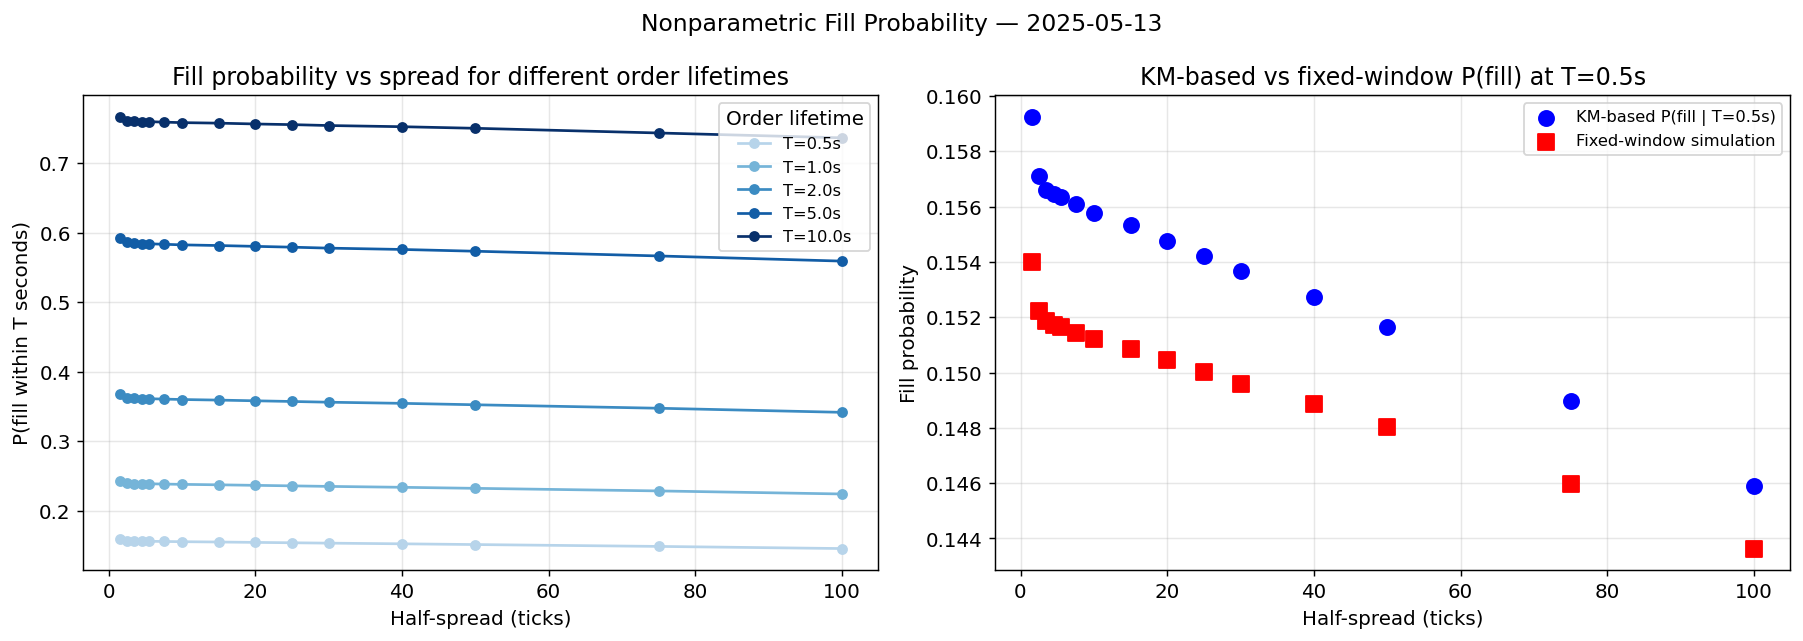

In [34]:
# Plot fill probability curves for different lifetimes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_T = plt.cm.Blues(np.linspace(0.3, 1.0, len(lifetimes)))
for T, col in zip(lifetimes, colors_T):
    probs = [fill_prob_at_lifetime(d, T) for d in DELTAS]
    axes[0].plot(DELTAS, probs, 'o-', color=col, lw=1.5, markersize=5,
                 label=f'T={T:.1f}s')

axes[0].set_xlabel('Half-spread (ticks)')
axes[0].set_ylabel('P(fill within T seconds)')
axes[0].set_title('Fill probability vs spread for different order lifetimes')
axes[0].legend(fontsize=9, title='Order lifetime')
axes[0].grid(alpha=0.3)

# Compare KM-based with fixed-window approach
# Fixed window approach: P(fill | delta, T=0.5s)
km_05 = [fill_prob_at_lifetime(d, 0.5) for d in DELTAS]

# Fixed window simulation
fp_fixed = simulate_fill_curve(trades, quotes, deltas=DELTAS,
                                 latency=LATENCY, quote_interval=0.5, verbose=False)

axes[1].scatter(DELTAS, km_05, s=70, color='blue', zorder=4,
                label='KM-based P(fill | T=0.5s)')
axes[1].scatter(fp_fixed['delta'], fp_fixed['fill_prob'], s=70,
                color='red', marker='s', zorder=4, label='Fixed-window simulation')
axes[1].set_xlabel('Half-spread (ticks)')
axes[1].set_ylabel('Fill probability')
axes[1].set_title('KM-based vs fixed-window P(fill) at T=0.5s')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Nonparametric Fill Probability — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/survival_fill_prob_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparison with Fixed-Window Approach

Key question: how different are kappa estimates between survival MLE and fixed-window?

In [35]:
from hft_market_maker.core.fill_analysis import compare_fits

# Fixed window fill curve (Approach B from kappa_analysis)
fp_fixed_full = simulate_fill_curve(trades, quotes, deltas=DELTAS,
                                      latency=LATENCY, quote_interval=0.5, verbose=False)
comp_fixed = compare_fits(fp_fixed_full)

# Survival-based fill curve at T=0.5s
fp_surv = pd.DataFrame({
    'delta': DELTAS,
    'fill_prob': [fill_prob_at_lifetime(d, 0.5) for d in DELTAS]
})
fp_surv = fp_surv[fp_surv['fill_prob'] > 0]
comp_surv = compare_fits(fp_surv)

# Hazard-based: fit directly to lambda_exp
print('Comparison of kappa estimates:')
print(f'  Fixed-window (pure exp):  kappa={comp_fixed["exponential"]["kappa"]:.4f}  '
      f'R2={comp_fixed["exponential"]["r2"]:.4f}')
print(f'  Fixed-window (shifted):   kappa={comp_fixed["shifted"]["kappa"]:.4f}  '
      f'A_mom={comp_fixed["shifted"]["A_floor"]:.4f}  '
      f'R2={comp_fixed["shifted"]["r2"]:.4f}')
print()
print(f'  Survival KM (pure exp):   kappa={comp_surv["exponential"]["kappa"]:.4f}  '
      f'R2={comp_surv["exponential"]["r2"]:.4f}')
print(f'  Survival KM (shifted):    kappa={comp_surv["shifted"]["kappa"]:.4f}  '
      f'A_mom={comp_surv["shifted"]["A_floor"]:.4f}  '
      f'R2={comp_surv["shifted"]["r2"]:.4f}')
print()
if A_surv:
    print(f'  Survival MLE direct:      kappa={kappa_surv:.4f}  (from hazard rate fit)')
if A_liq_surv:
    print(f'  Survival MLE shifted:     kappa={kappa_sh_surv:.4f}  A_mom={A_floor_surv:.4f}')

print()
print('Key insight: censoring fraction per spread distance:')
for _, row in surv_summary.iterrows():
    cens_rate = (row['n_diverged'] + row['n_timeout']) / row['n']
    print(f'  delta={row["delta"]:.1f}  censored={cens_rate:.3f}  '
          f'(diverged={row["n_diverged"]/row["n"]:.3f}  timeout={row["n_timeout"]/row["n"]:.3f})')

Comparison of kappa estimates:
  Fixed-window (pure exp):  kappa=0.0006  R2=0.9639
  Fixed-window (shifted):   kappa=0.0100  A_mom=0.1395  R2=0.9585

  Survival KM (pure exp):   kappa=0.0008  R2=0.9676
  Survival KM (shifted):    kappa=0.0100  A_mom=0.1406  R2=0.9606

  Survival MLE direct:      kappa=0.0100  (from hazard rate fit)
  Survival MLE shifted:     kappa=0.0100  A_mom=0.1433

Key insight: censoring fraction per spread distance:
  delta=1.5  censored=0.234  (diverged=0.003  timeout=0.232)
  delta=2.5  censored=0.244  (diverged=0.011  timeout=0.233)
  delta=3.5  censored=0.246  (diverged=0.013  timeout=0.233)
  delta=4.5  censored=0.247  (diverged=0.014  timeout=0.233)
  delta=5.5  censored=0.248  (diverged=0.014  timeout=0.233)
  delta=7.5  censored=0.249  (diverged=0.016  timeout=0.233)
  delta=10.0  censored=0.251  (diverged=0.017  timeout=0.233)
  delta=15.0  censored=0.252  (diverged=0.019  timeout=0.233)
  delta=20.0  censored=0.255  (diverged=0.021  timeout=0.233)
  del

## 7. Hysteresis Analysis

How often would quotes actually change under a hysteresis rule?
This justifies the decoupled recomputation architecture.

In [36]:
def analyse_hysteresis(
    quotes,
    half_spread_ticks,
    recompute_freq=RECOMPUTE_FREQ,
    tolerance_ticks_range=None,
    tick=TICK,
):
    """
    At each recompute_freq step, compute new optimal mid and check if
    it diverges from current quote by more than tolerance.

    Returns DataFrame with requote rate for each tolerance level.
    """
    if tolerance_ticks_range is None:
        tolerance_ticks_range = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0]

    quotes_ts  = (quotes['ts'].astype(np.int64) / 1e9).values
    quotes_mid = quotes['mid'].values

    t = quotes_ts[0]
    t_max = quotes_ts[-1]

    current_mid = quotes_mid[0]
    mid_history = []
    time_history = []

    while t < t_max:
        q_idx = np.searchsorted(quotes_ts, t, side='right') - 1
        if q_idx >= 0:
            mid_history.append(quotes_mid[q_idx])
            time_history.append(t)
        t += recompute_freq

    mids = np.array(mid_history)
    mid_changes = np.abs(np.diff(mids))  # change in mid per recompute step

    results = []
    for tol_ticks in tolerance_ticks_range:
        tol = tol_ticks * tick
        # Requote triggered when mid moves by more than tolerance
        requote_triggered = mid_changes > tol
        requote_rate = requote_triggered.mean()
        # Effective requote interval
        if requote_rate > 0:
            effective_interval = recompute_freq / requote_rate
        else:
            effective_interval = np.inf
        results.append({
            'tolerance_ticks': tol_ticks,
            'requote_rate': requote_rate,
            'effective_interval_s': effective_interval,
            'n_requotes_per_hour': requote_rate / recompute_freq * 3600,
        })

    return pd.DataFrame(results)


hyst_df = analyse_hysteresis(quotes, half_spread_ticks=1.5)

print('Hysteresis analysis — requote rate vs tolerance:')
print(f'{"Tolerance":>12} {"Requote rate":>14} {"Eff interval":>14} {"Requotes/hr":>14}')
print('-' * 58)
for _, row in hyst_df.iterrows():
    print(f'{row["tolerance_ticks"]:>12.2f} ticks  '
          f'{row["requote_rate"]:>10.4f}      '
          f'{row["effective_interval_s"]:>10.3f}s      '
          f'{row["n_requotes_per_hour"]:>10.0f}')

Hysteresis analysis — requote rate vs tolerance:
   Tolerance   Requote rate   Eff interval    Requotes/hr
----------------------------------------------------------
        0.00 ticks      0.0352           2.843s            1266
        0.25 ticks      0.0352           2.843s            1266
        0.50 ticks      0.0352           2.843s            1266
        1.00 ticks      0.0346           2.886s            1247
        1.50 ticks      0.0341           2.929s            1229
        2.00 ticks      0.0341           2.936s            1226
        3.00 ticks      0.0339           2.946s            1222


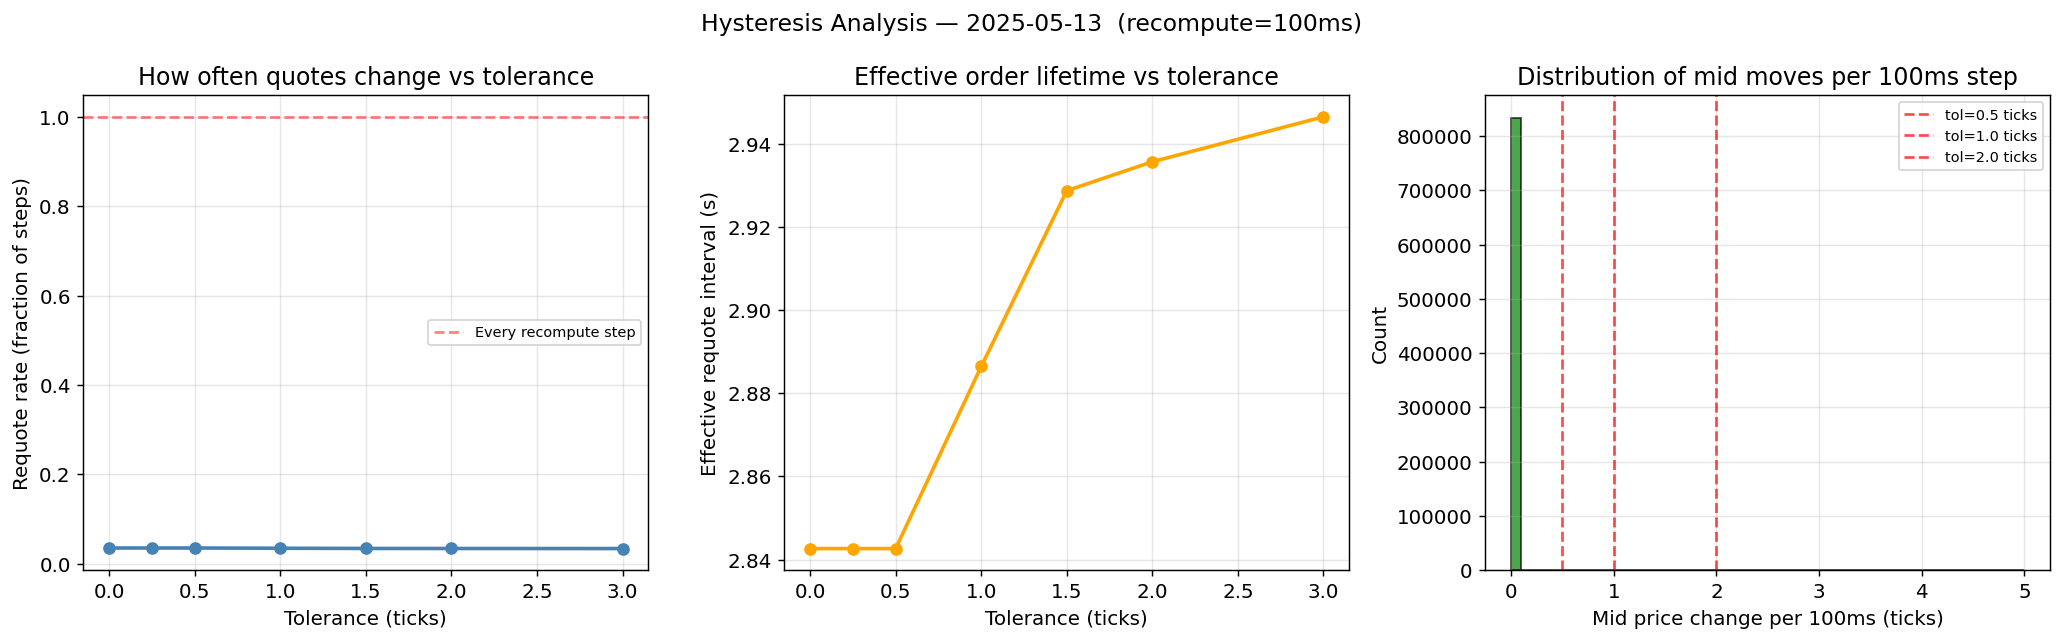

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(hyst_df['tolerance_ticks'], hyst_df['requote_rate'],
             'o-', color='steelblue', lw=2)
axes[0].axhline(1.0, color='red', ls='--', alpha=0.5, label='Every recompute step')
axes[0].set_xlabel('Tolerance (ticks)')
axes[0].set_ylabel('Requote rate (fraction of steps)')
axes[0].set_title('How often quotes change vs tolerance')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(hyst_df['tolerance_ticks'],
             hyst_df['effective_interval_s'].clip(upper=30),
             'o-', color='orange', lw=2)
axes[1].set_xlabel('Tolerance (ticks)')
axes[1].set_ylabel('Effective requote interval (s)')
axes[1].set_title('Effective order lifetime vs tolerance')
axes[1].grid(alpha=0.3)

# Mid price change distribution
quotes_ts  = (quotes['ts'].astype(np.int64) / 1e9).values
quotes_mid = quotes['mid'].values
t = quotes_ts[0]
mids = []
while t < quotes_ts[-1]:
    q_idx = np.searchsorted(quotes_ts, t, side='right') - 1
    if q_idx >= 0:
        mids.append(quotes_mid[q_idx])
    t += RECOMPUTE_FREQ
mid_changes = np.abs(np.diff(mids)) / TICK  # in ticks

axes[2].hist(mid_changes[mid_changes < 5], bins=50,
             color='green', alpha=0.7, edgecolor='black')
for tol in [0.5, 1.0, 2.0]:
    axes[2].axvline(tol, color='red', ls='--', alpha=0.7, label=f'tol={tol} ticks')
axes[2].set_xlabel('Mid price change per 100ms (ticks)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Distribution of mid moves per {int(RECOMPUTE_FREQ*1000)}ms step')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(f'Hysteresis Analysis — {DATE}  (recompute={int(RECOMPUTE_FREQ*1000)}ms)', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/hysteresis_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

In [38]:
print('=' * 65)
print('SURVIVAL ANALYSIS SUMMARY')
print('=' * 65)
print(f'Date:              {DATE}')
print(f'Recompute freq:    {int(RECOMPUTE_FREQ*1000)}ms')
print(f'Max lifetime:      {MAX_LIFETIME}s')
print(f'Tolerance:         {TOLERANCE_TICKS} ticks')
print()

print('Censoring structure (fraction of orders censored vs filled):')
for _, row in surv_summary.iterrows():
    print(f'  delta={row["delta"]:.1f}  filled={row["fill_rate"]:.3f}  '
          f'diverged={row["n_diverged"]/row["n"]:.3f}  '
          f'timeout={row["n_timeout"]/row["n"]:.3f}')

print()
print('Hazard rate estimates (survival MLE):')
if A_surv:
    print(f'  Pure exp:  A={A_surv:.4f}  kappa={kappa_surv:.4f}')
if A_liq_surv:
    print(f'  Shifted:   A_liq={A_liq_surv:.4f}  kappa={kappa_sh_surv:.4f}  '
          f'A_mom={A_floor_surv:.4f}  '
          f'mom%={A_floor_surv/(A_liq_surv+A_floor_surv)*100:.1f}%')

print()
print('Hysteresis recommendation:')
# Find tolerance where effective interval > 2s
good_tol = hyst_df[hyst_df['effective_interval_s'] > 2.0]
if len(good_tol) > 0:
    rec_tol = good_tol.iloc[0]
    print(f'  Tolerance={rec_tol["tolerance_ticks"]:.2f} ticks gives '
          f'effective interval={rec_tol["effective_interval_s"]:.1f}s')
    print(f'  ({rec_tol["n_requotes_per_hour"]:.0f} requotes/hour vs '
          f'{3600/RECOMPUTE_FREQ:.0f} without hysteresis)')

print()
print('Weibull shape k — time-varying hazard:')
k_mean = hz_weib['k_weibull'].mean()
print(f'  Mean k={k_mean:.4f}  (k<1 = hazard decreases over time)')
if k_mean < 1:
    print(f'  Fills are more likely soon after order submission')
    print(f'  Consistent with informed flow hitting stale quotes')
else:
    print(f'  Hazard roughly constant — exponential model reasonable')

SURVIVAL ANALYSIS SUMMARY
Date:              2025-05-13
Recompute freq:    100ms
Max lifetime:      10.0s
Tolerance:         1 ticks

Censoring structure (fraction of orders censored vs filled):
  delta=1.5  filled=0.766  diverged=0.003  timeout=0.232
  delta=2.5  filled=0.756  diverged=0.011  timeout=0.233
  delta=3.5  filled=0.754  diverged=0.013  timeout=0.233
  delta=4.5  filled=0.753  diverged=0.014  timeout=0.233
  delta=5.5  filled=0.752  diverged=0.014  timeout=0.233
  delta=7.5  filled=0.751  diverged=0.016  timeout=0.233
  delta=10.0  filled=0.749  diverged=0.017  timeout=0.233
  delta=15.0  filled=0.748  diverged=0.019  timeout=0.233
  delta=20.0  filled=0.745  diverged=0.021  timeout=0.233
  delta=25.0  filled=0.743  diverged=0.024  timeout=0.233
  delta=30.0  filled=0.740  diverged=0.026  timeout=0.233
  delta=40.0  filled=0.737  diverged=0.030  timeout=0.233
  delta=50.0  filled=0.732  diverged=0.034  timeout=0.234
  delta=75.0  filled=0.719  diverged=0.047  timeout=0.234

In [39]:
from scipy.stats import norm
from scipy.optimize import brentq
import numpy as np

# Your empirical parameters
rho          = 0.18      # 1-second autocorrelation
sigma_dollar = 2.96      # $/sqrt(s)
A_mom        = 0.1433    # fills/sec
tick         = 0.01      # dollar per tick
T_hold       = 10.0      # seconds order lifetime
dt_fill      = 1/A_mom   # mean time between fills = 6.98s

# Finite horizon correction
ratio = rho * (1 - rho**T_hold) / (1 - rho)
print(f'ratio = {ratio:.4f}  (ρ/(1-ρ) infinite = {rho/(1-rho):.4f})')

# Solve for z_opt
def equation(z):
    mills = norm.pdf(z) / max(norm.cdf(-z), 1e-10)
    return (1 - ratio) - ratio * (mills**2 + z*mills - 1)

try:
    z_opt = brentq(equation, 0.001, 20)
    delta_star_dollar = z_opt * sigma_dollar * np.sqrt(dt_fill)
    delta_star_ticks  = delta_star_dollar / tick
    
    print(f'z_opt            = {z_opt:.4f}')
    print(f'delta* (dollars) = ${delta_star_dollar:.4f}')
    print(f'delta* (ticks)   = {delta_star_ticks:.1f} ticks')
    
    # Expected PnL per fill at delta*
    mills_opt = norm.pdf(z_opt) / norm.cdf(-z_opt)
    adverse   = (delta_star_dollar + sigma_dollar * np.sqrt(dt_fill) * mills_opt) * ratio
    pnl_per_fill = delta_star_dollar - adverse
    print(f'Revenue per fill = ${delta_star_dollar:.4f}')
    print(f'Adverse per fill = ${adverse:.4f}')
    print(f'PnL per fill     = ${pnl_per_fill:.4f}')
    print(f'PnL per hour     = ${pnl_per_fill * A_mom * 3600:.2f}')
    
except ValueError as e:
    print(f'No solution: {e}')
    print('Checking sign of equation at boundaries:')
    print(f'  z=0.001: {equation(0.001):.4f}')
    print(f'  z=20:    {equation(20):.4f}')

ratio = 0.2195  (ρ/(1-ρ) infinite = 0.2195)
No solution: f(a) and f(b) must have different signs
Checking sign of equation at boundaries:
  z=0.001: 0.8599
  z=20:    1.0000
